# 5.25 — Training a Logistic Regression Classification Model

This notebook demonstrates a **binary classification** workflow using **Logistic Regression**.

Goals:

- Train a **majority-class baseline** (`DummyClassifier(most_frequent)`).
- Train **Logistic Regression** as an interpretable benchmark.
- Evaluate using **accuracy, precision, recall, F1**, and (when defined) **ROC-AUC**.
- Interpret coefficients as **odds ratios**.

CLI equivalent:

```bash
python -m src.main train
```

## 1) Setup: imports and repo path

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Ensure the repository root (folder containing `src/`) is on sys.path
cwd = Path.cwd().resolve()
for p in [cwd, *cwd.parents]:
    if (p / "src").is_dir():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Could not find repository root containing 'src/'")

import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

from src.config import (
    ALL_FEATURES,
    EXCLUDED_COLUMNS,
    NUMERICAL_FEATURES,
    CATEGORICAL_FEATURES,
    TARGET_SOURCE_COLUMN,
)
from src.data_loader import load_training_frame
from src.evaluate import evaluate_model
from src.feature_engineering import engineer_features
from src.preprocessing import (
    fit_preprocessor,
    separate_features_and_target,
    transform_features,
)

RANDOM_STATE = 42

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)


## 2) Load data and define a binary classification target

For the demo dataset, we derive a binary target from `yield_kg`:

- class 1: `yield_kg >= median(yield_kg)`
- class 0: otherwise

In [2]:
df = load_training_frame()

median_yield = float(df[TARGET_SOURCE_COLUMN].median())
working = df.copy()
working["target"] = (working[TARGET_SOURCE_COLUMN] >= median_yield).astype(int)

print("Target distribution:")
print(working["target"].value_counts())

available_features = [c for c in ALL_FEATURES if c in working.columns]
X, y = separate_features_and_target(
    working,
    target_column="target",
    feature_columns=available_features,
    excluded_columns=EXCLUDED_COLUMNS,
)

X = engineer_features(X)

X.head()

Target distribution:
target
1    2
0    2
Name: count, dtype: int64


,price,crop,region
0,2100,Rice,Maharashtra
1,1950,Wheat,Karnataka
2,1800,Maize,Gujarat
3,5000,Cotton,Telangana


## 3) Train/test split (with stratification)

Stratification helps preserve class proportions in both splits.

On very small datasets, you may need a larger test split to keep *both* classes present in the test set.

In [3]:
# For the tiny demo dataset, use 50/50 so the test set can contain both classes.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train target counts:\n", y_train.value_counts())
print("\nTest target counts:\n", y_test.value_counts())

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]

Train target counts:
 target
1    1
0    1
Name: count, dtype: int64

Test target counts:
 target
1    1
0    1
Name: count, dtype: int64


## 4) Preprocess (fit on train only)

We fit preprocessing on training data only to avoid leakage:

- numeric features are scaled
- categorical features are one-hot encoded

In [4]:
preprocessor = fit_preprocessor(
    X_train,
    numeric_features=NUMERICAL_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    numeric_scaler="standard",
)

X_train_p = transform_features(X_train, preprocessor)
X_test_p = transform_features(X_test, preprocessor)

print("Prepared train shape:", X_train_p.shape)
print("Prepared test shape:", X_test_p.shape)

X_train_p.head()

Prepared train shape: (2, 5)
Prepared test shape: (2, 5)


,price,crop_Cotton,crop_Rice,region_Maharashtra,region_Telangana
0,-1.0,0.0,1.0,1.0,0.0
3,1.0,1.0,0.0,0.0,1.0


## 5) Baseline vs Logistic Regression

- Baseline: always predict the most frequent class.
- Model: Logistic Regression outputs class probabilities via the sigmoid.

In [5]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train_p, y_train)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_p, y_train)

baseline_metrics = evaluate_model(baseline, X_test_p, y_test)
logreg_metrics = evaluate_model(logreg, X_test_p, y_test)

metrics_table = pd.DataFrame(
    [baseline_metrics, logreg_metrics],
    index=["Baseline (most_frequent)", "Logistic Regression"],
)[["accuracy", "precision", "recall", "f1_score", "roc_auc"]]

metrics_table

,accuracy,precision,recall,f1_score,roc_auc
Baseline (most_frequent),0.5,0.0,0.0,0.000000,0.5
Logistic Regression,0.5,0.5,1.0,0.666667,0.0


### Confusion matrix (Logistic Regression)

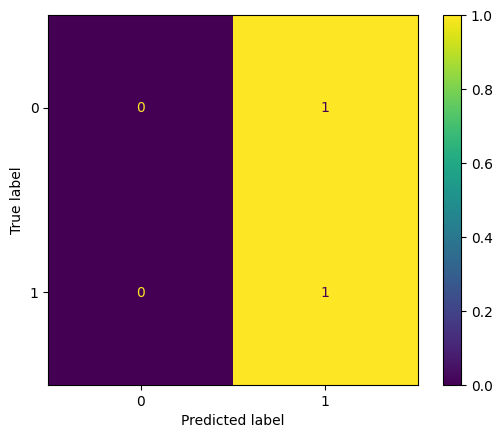

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, logreg.predict(X_test_p))

## 6) Interpret coefficients (odds ratios)

Logistic Regression coefficients live in **log-odds** space.

Exponentiating gives **odds ratios**:

- odds ratio $> 1$: increases odds of class 1
- odds ratio $< 1$: decreases odds of class 1

Coefficient magnitudes are easier to compare when numeric features are scaled.

In [7]:
coef = pd.Series(logreg.coef_[0], index=X_train_p.columns)
odds_ratio = np.exp(coef)

coef_df = (
    pd.DataFrame({"coefficient": coef, "odds_ratio": odds_ratio})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns=["abs_coef"])
)

print("Intercept:", float(logreg.intercept_[0]))
coef_df.head(15)

Intercept: 3.018791575426975e-17


,coefficient,odds_ratio
price,-0.521301,0.593748
crop_Rice,0.260650,1.297774
region_Maharashtra,0.260650,1.297774
crop_Cotton,-0.260650,0.770550
region_Telangana,-0.260650,0.770550


## 7) Cross-validation (ROC-AUC and F1)

Cross-validation gives more stable estimates than a single split.

Notes:

- ROC-AUC needs **both classes** to be present in each test fold.
- We use `StratifiedKFold` to preserve class proportions.

In [8]:
# For CV we re-fit preprocessing within each fold by building a single estimator pipeline.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = [c for c in NUMERICAL_FEATURES if c in X.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X.columns]

cv_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

cv_pipeline = Pipeline(
    steps=[
        ("preprocess", cv_preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

class_counts = y.value_counts()
max_splits = int(class_counts.min())
n_splits = min(5, max_splits)

if n_splits >= 2:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    cv_auc = cross_val_score(cv_pipeline, X, y, cv=cv, scoring="roc_auc").astype(float)
    cv_f1 = cross_val_score(cv_pipeline, X, y, cv=cv, scoring="f1").astype(float)

    print("CV ROC-AUC:", np.round(cv_auc, 3))
    print(f"Mean AUC:   {float(cv_auc.mean()):.3f} ± {float(cv_auc.std()):.3f}")

    print("\nCV F1:", np.round(cv_f1, 3))
    print(f"Mean F1: {float(cv_f1.mean()):.3f} ± {float(cv_f1.std()):.3f}")
else:
    print("Not enough samples per class for stratified CV (need at least 2 per class).")

CV ROC-AUC: [0. 0.]
Mean AUC:   0.000 ± 0.000

CV F1: [0.667 0.667]
Mean F1: 0.667 ± 0.000
